# 电影推荐系统模型对比实验

本 Notebook 用于完成课程要求中的“模型训练与评估”和“对比实验”部分。实验会对比两个基于物品的协同过滤模型：

- `baseline_numpy_item_cf`：`src/model.py` 中的 NumPy 手写余弦相似度基线模型。
- `sklearn_centered_item_cf`：`src/cf_recommender.py` 中使用 `scikit-learn` 计算余弦相似度，并加入用户均值中心化的改进模型。

为了保证对比公平，两个模型使用同一份训练集/测试集划分、同一批测试用户和同一套评价指标。

## 1. 环境准备与数据加载

加载项目源码、过滤后的用户-电影评分矩阵，并记录后续报告中可直接引用的实验设置。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cf_recommender import attach_movie_titles, load_movie_title_map
from src.evaluation import (
    BASELINE_ALGORITHM,
    SKLEARN_ALGORITHM,
    compare_models,
    load_filtered_matrix,
    recommend_for_user,
    repeated_compare_models,
    sensitivity_analysis,
    summarize_repeated_results,
    train_test_split_matrix,
)

sns.set_theme(style='whitegrid')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']

TEST_SIZE = 0.2
RANDOM_STATE = 42
TOP_N = 10
RELEVANCE_THRESHOLD = 4.0
REPEATED_RANDOM_STATES = (0, 1, 2, 3, 4)
EVALUATION_METRICS = ['RMSE', 'MAE', 'Weighted_RMSE', 'Weighted_MAE', 'Precision@K', 'Recall@K', 'HitRate@K']
TOPN_METRICS = ['Precision@K', 'Recall@K', 'HitRate@K']

matrix = load_filtered_matrix()
n_users, n_items = matrix.shape
n_ratings = int(matrix.notna().sum().sum())
sparsity = 1 - n_ratings / (n_users * n_items)

experiment_config = {
    'dataset': 'MovieLens ml-latest-small',
    'filter_rule': 'user ratings >= 30, movie ratings >= 15',
    'matrix_shape': matrix.shape,
    'rating_count': n_ratings,
    'sparsity': round(sparsity, 4),
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'top_n': TOP_N,
    'relevance_threshold': 'rating >= 4.0',
    'repeated_random_states': REPEATED_RANDOM_STATES,
}

print('project_root:', project_root)
display(pd.Series(experiment_config, name='value'))
display(matrix.head())

project_root: D:\Movie-Recommender-System


dataset                                 MovieLens ml-latest-small
filter_rule               user ratings >= 30, movie ratings >= 15
matrix_shape                                          (475, 1617)
rating_count                                                70454
sparsity                                                   0.9083
test_size                                                     0.2
random_state                                                   42
top_n                                                          10
relevance_threshold                                 rating >= 4.0
repeated_random_states                            (0, 1, 2, 3, 4)
Name: value, dtype: object

,1,2,3,5,6,7,10,11,12,14,...,138036,139385,142488,148626,152081,158238,164179,166528,168252,176371
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. 固定训练集与测试集

按用户维度随机抽取一部分已评分电影作为测试集，其余评分作为训练集。这样可以模拟“隐藏用户一部分历史评分，再检查模型能否预测出来”的评估过程。

本 notebook 默认使用全部有测试评分的用户进行正式全量对比；如需临时快速调试，可把 `eval_user_count` 改为 `20`。

In [2]:
train_matrix, test_matrix = train_test_split_matrix(
    matrix,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

eval_user_count = None
all_eval_user_ids = [uid for uid in test_matrix.index if test_matrix.loc[uid].notna().any()]
eval_user_ids = all_eval_user_ids if eval_user_count is None else all_eval_user_ids[:eval_user_count]

split_summary = pd.Series(
    {
        'train_shape': train_matrix.shape,
        'test_shape': test_matrix.shape,
        'train_ratings': int(train_matrix.notna().sum().sum()),
        'test_ratings': int(test_matrix.notna().sum().sum()),
        'evaluation_users': len(eval_user_ids),
        'evaluation_test_ratings': int(test_matrix.loc[eval_user_ids].notna().sum().sum()),
    },
    name='value',
)
display(split_summary)

train_shape                (475, 1617)
test_shape                 (475, 1617)
train_ratings                    56361
test_ratings                     14093
evaluation_users                   475
evaluation_test_ratings          14093
Name: value, dtype: object

## 3. 基线模型与 sklearn 模型整体对比

评价指标说明：

- `RMSE`：均方根误差，越低越好。
- `MAE`：平均绝对误差，越低越好。
- `Precision@K`：Top-K 推荐中命中相关电影的比例，越高越好。
- `Recall@K`：用户相关电影中被推荐命中的比例，越高越好。

In [3]:
algorithms = [BASELINE_ALGORITHM, SKLEARN_ALGORITHM]

comparison = compare_models(
    matrix,
    algorithms=algorithms,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    top_k_neighbors=20,
    top_n=TOP_N,
    relevance_threshold=RELEVANCE_THRESHOLD,
    user_ids=eval_user_ids,
)

column_names = {
    'algorithm': 'model',
    'top_k_neighbors': 'top_k_neighbors',
    'top_n': 'top_n',
    'n_users': 'n_users',
    'n_test_ratings': 'n_test_ratings',
    'n_users_with_relevant_items': 'n_users_with_relevant_items',
    'Weighted_RMSE': 'Weighted_RMSE',
    'Weighted_MAE': 'Weighted_MAE',
    'HitRate@K': 'HitRate@K',
    'Precision@K_relevant_users': 'Precision@K_relevant_users',
    'Recall@K_relevant_users': 'Recall@K_relevant_users',
    'HitRate@K_relevant_users': 'HitRate@K_relevant_users',
}
comparison_display = comparison.rename(columns=column_names)
display(comparison_display)

,model,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE,MAE,Weighted_RMSE,Weighted_MAE,Precision@K,Recall@K,HitRate@K,Precision@K_relevant_users,Recall@K_relevant_users,HitRate@K_relevant_users
0,baseline_numpy_item_cf,20,10,475,14093,469,0.822211,0.661575,0.828074,0.631292,0.060842,0.030942,0.336842,0.061620,0.031338,0.341151
1,sklearn_centered_item_cf,20,10,475,14093,469,0.798196,0.638230,0.802795,0.608938,0.064842,0.028754,0.317895,0.065672,0.029122,0.321962


## 4. 评价指标柱状图

下面把两个模型的 RMSE、MAE、Precision@K 和 Recall@K 画成柱状图，方便观察误差指标与推荐命中指标的差异。

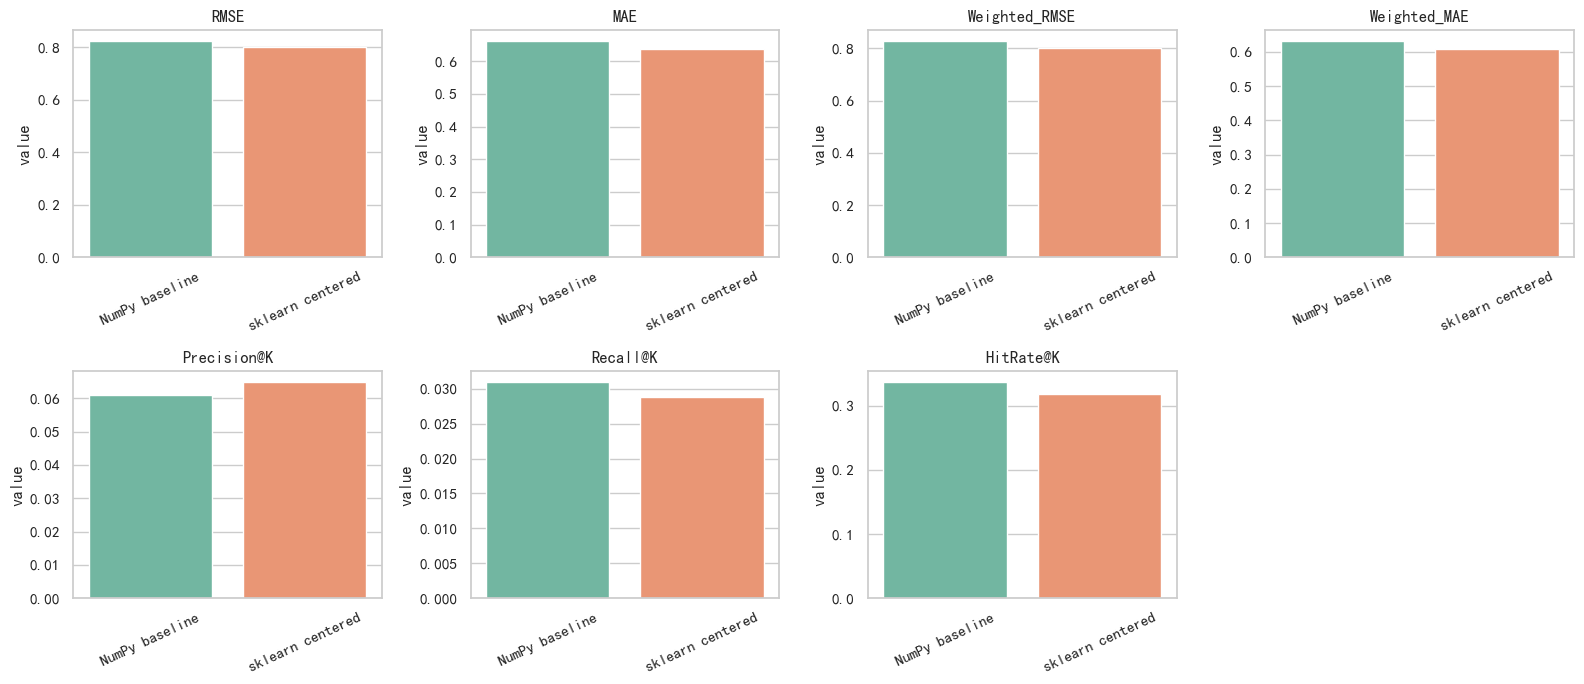

In [4]:
metric_labels = EVALUATION_METRICS
plot_source = comparison.copy()
plot_source.attrs = {}
plot_df = plot_source.melt(
    id_vars=['algorithm'],
    value_vars=metric_labels,
    var_name='metric',
    value_name='value',
)
plot_df['model_label'] = plot_df['algorithm'].map({
    BASELINE_ALGORITHM: 'NumPy baseline',
    SKLEARN_ALGORITHM: 'sklearn centered',
})

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for ax, metric in zip(axes, metric_labels):
    current = plot_df[plot_df['metric'] == metric]
    sns.barplot(data=current, x='model_label', y='value', ax=ax, hue='model_label', palette='Set2', legend=False)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
for ax in axes[len(metric_labels):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. 邻居数量 top_k 敏感性分析

协同过滤模型通常会受到邻居数量影响。这里测试 `top_k = 5, 10, 20, 40` 四组参数，观察不同模型在误差和推荐命中率上的变化。

In [5]:
sensitivity = sensitivity_analysis(
    matrix,
    top_k_values=(5, 10, 20, 40),
    top_n=TOP_N,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    relevance_threshold=RELEVANCE_THRESHOLD,
    user_ids=eval_user_ids,
    algorithms=algorithms,
)

sensitivity_display = sensitivity.rename(columns=column_names)
display(sensitivity_display)

,model,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE,MAE,Weighted_RMSE,Weighted_MAE,Precision@K,Recall@K,HitRate@K,Precision@K_relevant_users,Recall@K_relevant_users,HitRate@K_relevant_users
0,baseline_numpy_item_cf,5,10,475,14093,469,0.843858,0.669305,0.855462,0.647455,0.050947,0.029356,0.303158,0.051599,0.029732,0.307036
1,baseline_numpy_item_cf,10,10,475,14093,469,0.825110,0.660476,0.832462,0.632819,0.059368,0.031347,0.324211,0.060128,0.031748,0.328358
2,baseline_numpy_item_cf,20,10,475,14093,469,0.822211,0.661575,0.828074,0.631292,0.060842,0.030942,0.336842,0.061620,0.031338,0.341151
3,baseline_numpy_item_cf,40,10,475,14093,469,0.832254,0.672970,0.837124,0.639450,0.053053,0.024301,0.269474,0.053731,0.024611,0.272921
4,sklearn_centered_item_cf,5,10,475,14093,469,0.833013,0.660409,0.845300,0.638652,0.061895,0.035708,0.355789,0.062687,0.036165,0.360341
5,sklearn_centered_item_cf,10,10,475,14093,469,0.806611,0.642302,0.813188,0.616095,0.065474,0.034578,0.353684,0.066311,0.035021,0.358209
6,sklearn_centered_item_cf,20,10,475,14093,469,0.798196,0.638230,0.802795,0.608938,0.064842,0.028754,0.317895,0.065672,0.029122,0.321962
7,sklearn_centered_item_cf,40,10,475,14093,469,0.799682,0.641716,0.802078,0.609957,0.062947,0.030439,0.315789,0.063753,0.030828,0.319829


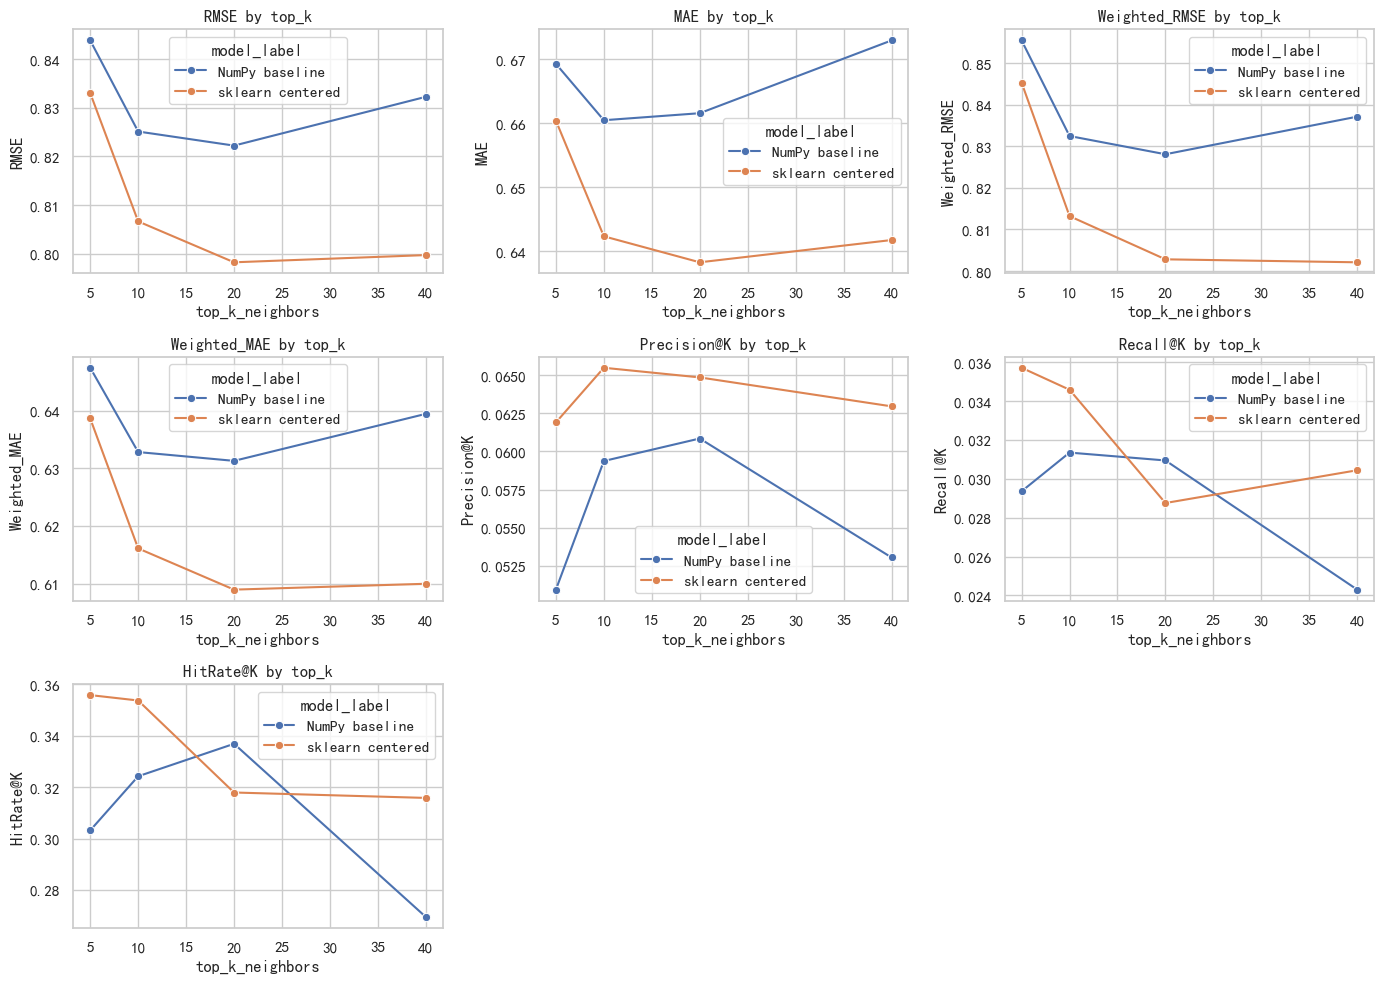

In [6]:
sensitivity_plot = sensitivity.copy()
sensitivity_plot['model_label'] = sensitivity_plot['algorithm'].map({
    BASELINE_ALGORITHM: 'NumPy baseline',
    SKLEARN_ALGORITHM: 'sklearn centered',
})

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()
for ax, metric in zip(axes, metric_labels):
    sns.lineplot(
        data=sensitivity_plot,
        x='top_k_neighbors',
        y=metric,
        hue='model_label',
        marker='o',
        ax=ax,
    )
    ax.set_title(f'{metric} by top_k')
    ax.set_xlabel('top_k_neighbors')
for ax in axes[len(metric_labels):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. 指定用户推荐案例

选取一个样例用户，分别输出两个模型的 Top-10 推荐电影。该部分用于解释模型是如何为具体用户生成推荐结果的，不作为整体评估结论。

In [7]:
sample_user = eval_user_ids[0]
movie_title_map = load_movie_title_map(project_root)

case_tables = []
for algorithm in algorithms:
    recommendations = recommend_for_user(
        train_matrix=train_matrix,
        user_id=sample_user,
        algorithm=algorithm,
        top_k_neighbors=20,
        top_n=TOP_N,
    )
    table = attach_movie_titles(recommendations, movie_title_map)
    table.insert(0, 'model', algorithm)
    case_tables.append(table)

case_recommendations = pd.concat(case_tables, ignore_index=True)
case_recommendations = case_recommendations.rename(columns={
    'movieId': 'movieId',
    'title': 'title',
    'pred_rating': 'pred_rating',
})
print('sample_user:', sample_user)
display(case_recommendations)

sample_user: 1


,model,movieId,title,pred_rating
0,baseline_numpy_item_cf,4878,Donnie Darko (2001),4.909863
1,baseline_numpy_item_cf,68358,Star Trek (2009),4.906412
2,baseline_numpy_item_cf,91529,"Dark Knight Rises, The (2012)",4.870069
3,baseline_numpy_item_cf,54272,"Simpsons Movie, The (2007)",4.859397
4,baseline_numpy_item_cf,778,Trainspotting (1996),4.859047
5,baseline_numpy_item_cf,4011,Snatch (2000),4.858327
6,baseline_numpy_item_cf,1221,"Godfather: Part II, The (1974)",4.854420
7,baseline_numpy_item_cf,7361,Eternal Sunshine of the Spotless Mind (2004),4.846946
8,baseline_numpy_item_cf,6711,Lost in Translation (2003),4.845205
9,baseline_numpy_item_cf,111659,Maleficent (2014),4.838988


## 7. 多随机种子稳定性评估

单次随机划分可以复现，但不足以说明模型差异是否稳定。本节使用多个随机种子重复全量评估，并汇总主要指标的均值和标准差。

In [8]:
repeated_results = repeated_compare_models(
    matrix=matrix,
    algorithms=algorithms,
    random_states=REPEATED_RANDOM_STATES,
    test_size=TEST_SIZE,
    top_k_neighbors=20,
    top_n=TOP_N,
    relevance_threshold=RELEVANCE_THRESHOLD,
)

repeated_summary = summarize_repeated_results(repeated_results)
repeated_display = repeated_summary.rename(columns=column_names)
display(repeated_results.rename(columns=column_names))
display(repeated_display)

,random_state,model,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE,MAE,Weighted_RMSE,Weighted_MAE,Precision@K,Recall@K,HitRate@K,Precision@K_relevant_users,Recall@K_relevant_users,HitRate@K_relevant_users
0,0,baseline_numpy_item_cf,20,10,475,14093,474,0.825647,0.661370,0.832684,0.634379,0.062105,0.030145,0.307368,0.062236,0.030209,0.308017
1,0,sklearn_centered_item_cf,20,10,475,14093,474,0.799887,0.633746,0.812728,0.614201,0.063158,0.027549,0.311579,0.063291,0.027607,0.312236
2,1,baseline_numpy_item_cf,20,10,475,14093,475,0.828536,0.662948,0.831946,0.632298,0.062316,0.034471,0.345263,0.062316,0.034471,0.345263
3,1,sklearn_centered_item_cf,20,10,475,14093,475,0.800171,0.637257,0.807703,0.611679,0.072632,0.032464,0.336842,0.072632,0.032464,0.336842
4,2,baseline_numpy_item_cf,20,10,475,14093,474,0.831945,0.667571,0.840109,0.638201,0.059579,0.032536,0.311579,0.059705,0.032604,0.312236
5,2,sklearn_centered_item_cf,20,10,475,14093,474,0.805669,0.641216,0.817996,0.618482,0.060211,0.030632,0.309474,0.060338,0.030697,0.310127
6,3,baseline_numpy_item_cf,20,10,475,14093,473,0.826466,0.663623,0.837406,0.636293,0.060000,0.029728,0.315789,0.060254,0.029854,0.317125
7,3,sklearn_centered_item_cf,20,10,475,14093,473,0.802720,0.639413,0.818937,0.617871,0.060421,0.026611,0.288421,0.060677,0.026724,0.289641
8,4,baseline_numpy_item_cf,20,10,475,14093,473,0.830222,0.664606,0.842554,0.638222,0.062105,0.028879,0.322105,0.062368,0.029001,0.323467
9,4,sklearn_centered_item_cf,20,10,475,14093,473,0.802214,0.640318,0.821239,0.618331,0.064211,0.027954,0.307368,0.064482,0.028072,0.308668


,model,top_k_neighbors,top_n,n_users,n_test_ratings,n_users_with_relevant_items,RMSE_mean,RMSE_std,MAE_mean,MAE_std,...,Recall@K_mean,Recall@K_std,HitRate@K_mean,HitRate@K_std,Precision@K_relevant_users_mean,Precision@K_relevant_users_std,Recall@K_relevant_users_mean,Recall@K_relevant_users_std,HitRate@K_relevant_users_mean,HitRate@K_relevant_users_std
0,baseline_numpy_item_cf,20,10,475,14093,474,0.828563,0.002602,0.664023,0.002307,...,0.031152,0.002299,0.320421,0.014916,0.061376,0.001290,0.031228,0.002253,0.321222,0.014620
1,sklearn_centered_item_cf,20,10,475,14093,474,0.802132,0.002332,0.638390,0.002983,...,0.029042,0.002427,0.310737,0.017271,0.064284,0.004982,0.029113,0.002388,0.311503,0.016811


## 8. 稳定性指标可视化

下面用误差条展示多次随机划分下的指标均值和标准差，便于判断两个模型的优势是否稳定。

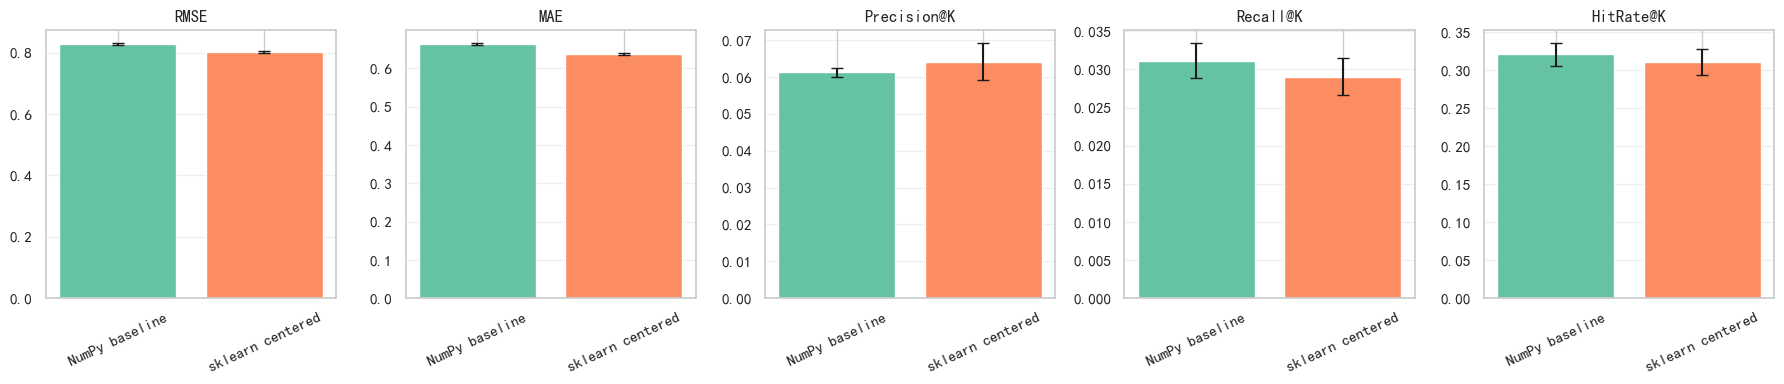

In [9]:
stable_metrics = ['RMSE', 'MAE', 'Precision@K', 'Recall@K', 'HitRate@K']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, metric in zip(axes, stable_metrics):
    means = repeated_summary[f'{metric}_mean']
    stds = repeated_summary[f'{metric}_std'].fillna(0.0)
    labels = repeated_summary['algorithm'].map({
        BASELINE_ALGORITHM: 'NumPy baseline',
        SKLEARN_ALGORITHM: 'sklearn centered',
    })
    ax.bar(labels, means, yerr=stds, capsize=4, color=['#66C2A5', '#FC8D62'])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 实验结论记录

- 本 notebook 使用全量可评估用户完成两个基于物品的协同过滤模型对比，结果可直接用于技术报告的“实验结果与分析”部分。
- `baseline_numpy_item_cf` 是手写 NumPy 基线模型，直接基于原始评分矩阵计算物品相似度。
- `sklearn_centered_item_cf` 使用 `scikit-learn` 计算余弦相似度，并通过用户均值中心化减少不同用户打分尺度差异。
- 评估结果同时报告 macro RMSE/MAE、weighted RMSE/MAE、Precision@K、Recall@K、HitRate@K 和有相关测试项用户数，避免只依赖单一口径。
- 单次全量结果中，`sklearn_centered_item_cf` 在 RMSE 和 MAE 上更优；`baseline_numpy_item_cf` 在当前 Precision@K、Recall@K 和 HitRate@K 上略高。
- 多随机种子稳定性评估用于判断这些差异是否稳定，最终分析应同时讨论评分预测误差和 Top-N 推荐命中率。